In [1]:
# import Providentia
import providentia as prv

In [2]:
# magic to make plots appear inline
%matplotlib inline

In [3]:
# initialise objects
provi_lev15 = prv.Providentia('foci_aeronet.conf', section='AERONET1.5', resolution='daily')
provi_lev15f = prv.Providentia('foci_aeronet.conf', section='AERONET1.5_FLAGL2', resolution='daily')
provi_lev20 = prv.Providentia('foci_aeronet.conf', section='AERONET2.0', resolution='daily')

In [6]:
# read and filter data from .conf
provi_lev15.load()
provi_lev15f.load()
provi_lev20.load()

Generating file trees...
Reading data

OBSERVATIONS
 - AERONET_v3_lev1.5|absae440-675aero
 - AERONET_v3_lev1.5|absae675-870aero
 - AERONET_v3_lev1.5|lsae440-675aero
 - AERONET_v3_lev1.5|abswdaeaero

Resetting data filters to when class was initialised, loading AERONET1.5 subsection filters.
Filtering data
Generating file trees...
Reading data

OBSERVATIONS
 - AERONET_v3_lev1.5|absae440-675aero
 - AERONET_v3_lev1.5|absae675-870aero
 - AERONET_v3_lev1.5|lsae440-675aero
 - AERONET_v3_lev1.5|abswdaeaero

Resetting data filters to when class was initialised, loading AERONET1.5_FLAGL2 subsection filters.
Filtering data
Generating file trees...
Reading data

OBSERVATIONS
 - AERONET_v3_lev2.0|absae440-675aero
 - AERONET_v3_lev2.0|absae675-870aero
 - AERONET_v3_lev2.0|lsae440-675aero
 - AERONET_v3_lev2.0|abswdaeaero

Resetting data filters to when class was initialised, loading AERONET2.0 subsection filters.
Filtering data


In [7]:
# get data in memory (in netCDF format)
import numpy as np

data_lev15 = provi_lev15.data(format='nc')
data_lev15f = provi_lev15f.data(format='nc')
data_lev20 = provi_lev20.data(format='nc')

aae1_lev15 = data_lev15['AERONET_v3_lev1.5|absae440-675aero_data'][:].flatten()
aae2_lev15 = data_lev15['AERONET_v3_lev1.5|absae675-870aero_data'][:].flatten()
sae1_lev15 = data_lev15['AERONET_v3_lev1.5|lsae440-675aero_data'][:].flatten()
wda_lev15 = data_lev15['AERONET_v3_lev1.5|abswdaeaero_data'][:].flatten()

aae1_lev15f = data_lev15f['AERONET_v3_lev1.5|absae440-675aero_data'][:].flatten()
aae2_lev15f = data_lev15f['AERONET_v3_lev1.5|absae675-870aero_data'][:].flatten()
sae1_lev15f = data_lev15f['AERONET_v3_lev1.5|lsae440-675aero_data'][:].flatten()
wda_lev15f = data_lev15f['AERONET_v3_lev1.5|abswdaeaero_data'][:].flatten()

aae1_lev20 = data_lev20['AERONET_v3_lev2.0|absae440-675aero_data'][:].flatten()
aae2_lev20 = data_lev20['AERONET_v3_lev2.0|absae675-870aero_data'][:].flatten()
sae1_lev20 = data_lev20['AERONET_v3_lev2.0|lsae440-675aero_data'][:].flatten()
wda_lev20 = data_lev20['AERONET_v3_lev2.0|abswdaeaero_data'][:].flatten()

In [8]:
# set colours for speciation
colours_lev15 = np.array(['#808080']*len(aae2_lev15))
colours_lev15f = np.array(['#808080']*len(aae2_lev15f))
colours_lev20 = np.array(['#808080']*len(aae2_lev20))

dust_indices_lev15 = (sae1_lev15 < 0.5) & (aae1_lev15 > 1.5)
carbonaceous_indices_lev15 = (sae1_lev15 > 1.2)
bc_indices_lev15 = (aae1_lev15 < 0.55) & (aae2_lev15 < 0.83)
colours_lev15[dust_indices_lev15] = '#FFA500'
colours_lev15[carbonaceous_indices_lev15] = '#964B00'
colours_lev15[bc_indices_lev15] = '#000000'
mixed_indices_lev15 = colours_lev15 == '#808080'
#aae2_lev15[dust_indices_lev15] = np.NaN
#aae2_lev15[carbonaceous_indices_lev15] = np.NaN
#aae2_lev15[bc_indices_lev15] = np.NaN
#aae2_lev15[mixed_indices_lev15] = np.NaN
#wda_lev15[dust_indices_lev15] = np.NaN
#wda_lev15[carbonaceous_indices_lev15] = np.NaN
#wda_lev15[bc_indices_lev15] = np.NaN
#wda_lev15[mixed_indices_lev15] = np.NaN

dust_indices_lev15f = (sae1_lev15f < 0.5) & (aae1_lev15f > 1.5)
carbonaceous_indices_lev15f = (sae1_lev15f > 1.2)
bc_indices_lev15f = (aae1_lev15f < 0.55) & (aae2_lev15f < 0.83)
colours_lev15f[dust_indices_lev15f] = '#FFA500'
colours_lev15f[carbonaceous_indices_lev15f] = '#964B00'
colours_lev15f[bc_indices_lev15f] = '#000000'
mixed_indices_lev15f = colours_lev15f == '#808080'
#aae2_lev15f[dust_indices_lev15f] = np.NaN
#aae2_lev15f[carbonaceous_indices_lev15f] = np.NaN
#aae2_lev15f[bc_indices_lev15f] = np.NaN
#aae2_lev15f[mixed_indices_lev15f] = np.NaN
#wda_lev15f[dust_indices_lev15f] = np.NaN
#wda_lev15f[carbonaceous_indices_lev15f] = np.NaN
#wda_lev15f[bc_indices_lev15f] = np.NaN
#wda_lev15f[mixed_indices_lev15f] = np.NaN

dust_indices_lev20 = (sae1_lev20 < 0.5) & (aae1_lev20 > 1.5)
carbonaceous_indices_lev20 = (sae1_lev20 > 1.2)
bc_indices_lev20 = (aae1_lev20 < 0.55) & (aae2_lev20 < 0.83)
colours_lev20[dust_indices_lev20] = '#FFA500'
colours_lev20[carbonaceous_indices_lev20] = '#964B00'
colours_lev20[bc_indices_lev20] = '#000000'
mixed_indices_lev20 = colours_lev20 == '#808080'
#aae2_lev20[dust_indices_lev20] = np.NaN
#aae2_lev20[carbonaceous_indices_lev20] = np.NaN
#aae2_lev20[bc_indices_lev20] = np.NaN
#aae2_lev20[mixed_indices_lev20] = np.NaN
#wda_lev20[dust_indices_lev20] = np.NaN
#wda_lev20[carbonaceous_indices_lev20] = np.NaN
#wda_lev20[bc_indices_lev20] = np.NaN
#wda_lev20[mixed_indices_lev20] = np.NaN


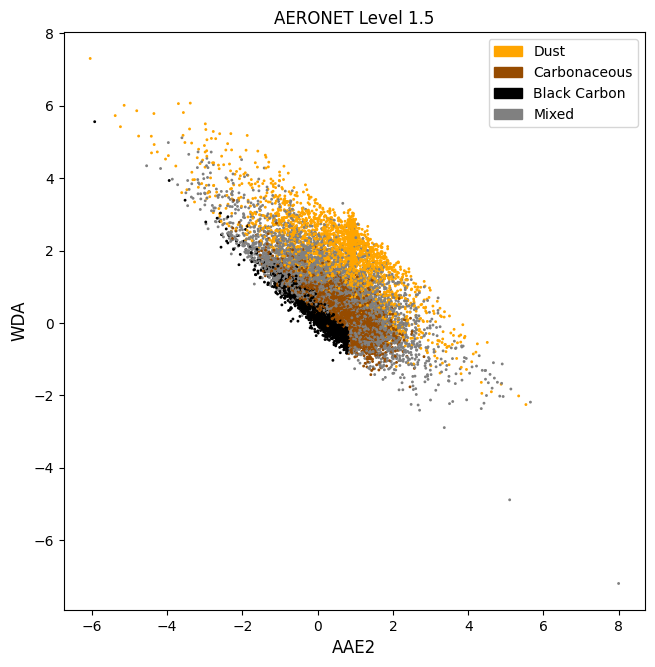

TOTAL: 45237

N DUST: 3205
N CARBONACEOUS: 27747
N BLACK CARBON: 4064
N MIXED: 12900
N FILTER SUM: 45237
N CARBONACEOUS/BLACK CARBON OVERLAP: 2679


In [9]:
# plot aae2 vs wda (AERONET level 1.5)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig = plt.figure(figsize=[7.5, 7.5])
ax = fig.add_subplot(111)
ax.scatter(aae2_lev15, wda_lev15, c=colours_lev15, s=1.1, marker='o')
ax.set_xlabel('AAE2', fontsize=12)
ax.set_ylabel('WDA', fontsize=12)

# make legend
dust_label = mpatches.Patch(color='#FFA500', label='Dust')
carbonaceous_label= mpatches.Patch(color='#964B00', label='Carbonaceous')
bc_label = mpatches.Patch(color='#000000', label='Black Carbon')
mixed_label = mpatches.Patch(color='#808080', label='Mixed')
handles = [dust_label, carbonaceous_label, bc_label, mixed_label]
ax.legend(handles=handles, loc='upper right')
ax.set_title('AERONET Level 1.5')

# show plot
plt.show()
plt.close()

valid_inds = ~np.isnan(aae2_lev15)
valid_inds2 = ~np.isnan(aae1_lev15)
valid_inds3 = ~np.isnan(sae1_lev15)
valid_inds4 = ~np.isnan(wda_lev15)

dust_inds = dust_indices_lev15.sum()
carbon_inds = carbonaceous_indices_lev15.sum()
bc_inds = bc_indices_lev15.sum()
total_carbon_inds = (carbonaceous_indices_lev15 | bc_indices_lev15).sum()
mixed_inds = mixed_indices_lev15[valid_inds].sum()

print('TOTAL:',valid_inds.sum())
print()
print('N DUST:',dust_inds)
print('N CARBONACEOUS:',carbon_inds)
print('N BLACK CARBON:',bc_inds)
print('N MIXED:',mixed_inds)
print('N FILTER SUM:',dust_inds+total_carbon_inds+mixed_inds)
print('N CARBONACEOUS/BLACK CARBON OVERLAP:',(carbonaceous_indices_lev15 & bc_indices_lev15).sum())

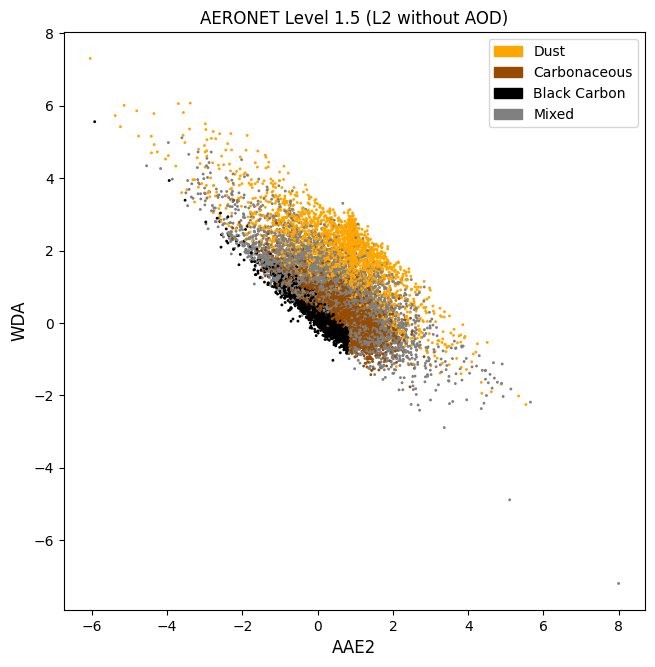

TOTAL: 43737

N DUST: 3112
N CARBONACEOUS: 26774
N BLACK CARBON: 3941
N MIXED: 12494
N FILTER SUM: 43737
N CARBONACEOUS/BLACK CARBON OVERLAP: 2584


In [10]:
# plot aae2 vs wda (AERONET level 1.5 with L2 flag)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig = plt.figure(figsize=[7.5, 7.5])
ax = fig.add_subplot(111)
ax.scatter(aae2_lev15f, wda_lev15f, c=colours_lev15f, s=1.1, marker='o')
ax.set_xlabel('AAE2', fontsize=12)
ax.set_ylabel('WDA', fontsize=12)

# make legend
dust_label = mpatches.Patch(color='#FFA500', label='Dust')
carbonaceous_label= mpatches.Patch(color='#964B00', label='Carbonaceous')
bc_label = mpatches.Patch(color='#000000', label='Black Carbon')
mixed_label = mpatches.Patch(color='#808080', label='Mixed')
handles = [dust_label, carbonaceous_label, bc_label, mixed_label]
ax.legend(handles=handles, loc='upper right')
ax.set_title('AERONET Level 1.5 (L2 without AOD)')

# show plot
plt.show()
plt.close()

valid_inds = ~np.isnan(aae2_lev15f)
dust_inds = dust_indices_lev15f.sum()
carbon_inds = carbonaceous_indices_lev15f.sum()
bc_inds = bc_indices_lev15f.sum()
total_carbon_inds = (carbonaceous_indices_lev15f | bc_indices_lev15f).sum()
mixed_inds = mixed_indices_lev15f[valid_inds].sum()

print('TOTAL:',valid_inds.sum())
print()
print('N DUST:',dust_inds)
print('N CARBONACEOUS:',carbon_inds)
print('N BLACK CARBON:',bc_inds)
print('N MIXED:',mixed_inds)
print('N FILTER SUM:',dust_inds+total_carbon_inds+mixed_inds)
print('N CARBONACEOUS/BLACK CARBON OVERLAP:',(carbonaceous_indices_lev15f & bc_indices_lev15f).sum())


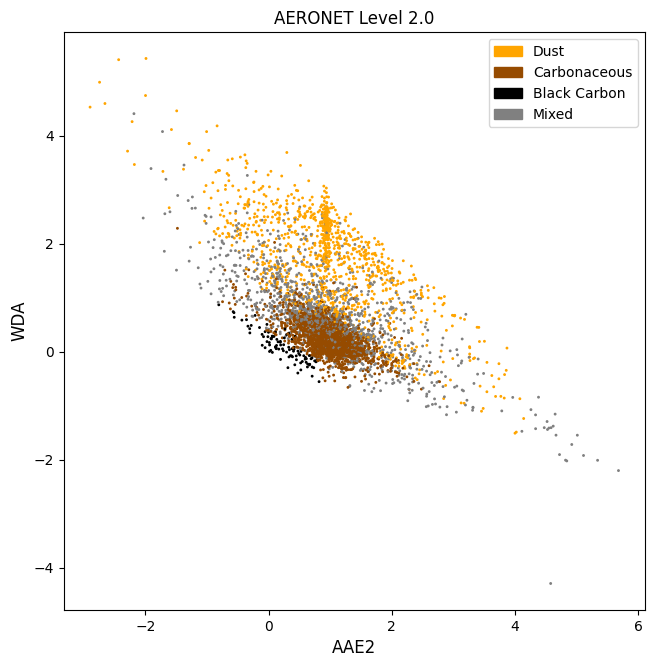

TOTAL: 5528

N DUST: 1124
N CARBONACEOUS: 2691
N BLACK CARBON: 103
N MIXED: 1691
N FILTER SUM: 5528
N CARBONACEOUS/BLACK CARBON OVERLAP: 81


In [11]:
# plot aae2 vs wda (AERONET level 2.0)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig = plt.figure(figsize=[7.5, 7.5])
ax = fig.add_subplot(111)
ax.scatter(aae2_lev20, wda_lev20, c=colours_lev20, s=1.1, marker='o')
ax.set_xlabel('AAE2', fontsize=12)
ax.set_ylabel('WDA', fontsize=12)

# make legend
dust_label = mpatches.Patch(color='#FFA500', label='Dust')
carbonaceous_label= mpatches.Patch(color='#964B00', label='Carbonaceous')
bc_label = mpatches.Patch(color='#000000', label='Black Carbon')
mixed_label = mpatches.Patch(color='#808080', label='Mixed')
handles = [dust_label, carbonaceous_label, bc_label, mixed_label]
ax.legend(handles=handles, loc='upper right')
ax.set_title('AERONET Level 2.0')

# show plot
plt.show()
plt.close()

valid_inds = ~np.isnan(aae2_lev20)
dust_inds = dust_indices_lev20.sum()
carbon_inds = carbonaceous_indices_lev20.sum()
bc_inds = bc_indices_lev20.sum()
total_carbon_inds = (carbonaceous_indices_lev20 | bc_indices_lev20).sum()
mixed_inds = mixed_indices_lev20[valid_inds].sum()

print('TOTAL:',valid_inds.sum())
print()
print('N DUST:',dust_inds)
print('N CARBONACEOUS:',carbon_inds)
print('N BLACK CARBON:',bc_inds)
print('N MIXED:',mixed_inds)
print('N FILTER SUM:',dust_inds+total_carbon_inds+mixed_inds)
print('N CARBONACEOUS/BLACK CARBON OVERLAP:',(carbonaceous_indices_lev20 & bc_indices_lev20).sum())
